1. Data Loading

In [ ]:
import torch
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)


{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [16]:
X.head()

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


2. Visualization of raw data

array([[<Axes: title={'center': 'sepal length'}>,
        <Axes: title={'center': 'sepal width'}>],
       [<Axes: title={'center': 'petal length'}>,
        <Axes: title={'center': 'petal width'}>]], dtype=object)

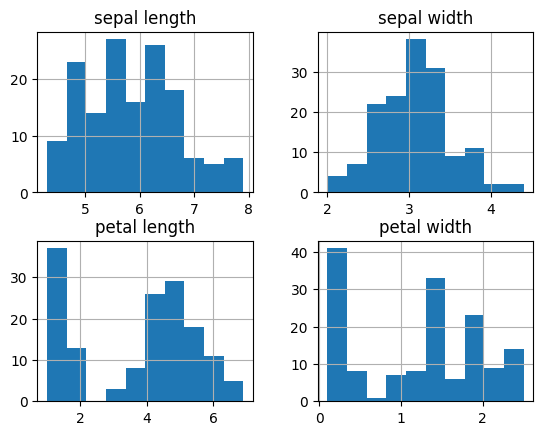

In [ ]:
viz=df[["sepal length","sepal width","petal length","petal width"]]
viz.hist()

In [ ]:
#after seeing the histograms and the correlations I decided to use K-Nearest Negihboors because its the most intuitive method for this
#dataset as classifying in 3 classes of Iris
#then the first step is standarizing everything as numbers including the classes so I can use pytorch

y["class"]=y["class"].map({"Iris-setosa":0,"Iris-versicolor":1,"Iris-virginica":2})

3. Train/test split

In [ ]:
features=df[["sepal length","sepal width","petal length","petal width"]].values

classes=y["class"].values
#now we have the values of features of sepal, petals and classes as an ndarray

#we convert the ndawways to tensors
f=torch.tensor(features)
c=torch.tensor(classes)

print(f)

tensor([[5.1000, 3.5000, 1.4000, 0.2000],
        [4.9000, 3.0000, 1.4000, 0.2000],
        [4.7000, 3.2000, 1.3000, 0.2000],
        [4.6000, 3.1000, 1.5000, 0.2000],
        [5.0000, 3.6000, 1.4000, 0.2000],
        [5.4000, 3.9000, 1.7000, 0.4000],
        [4.6000, 3.4000, 1.4000, 0.3000],
        [5.0000, 3.4000, 1.5000, 0.2000],
        [4.4000, 2.9000, 1.4000, 0.2000],
        [4.9000, 3.1000, 1.5000, 0.1000],
        [5.4000, 3.7000, 1.5000, 0.2000],
        [4.8000, 3.4000, 1.6000, 0.2000],
        [4.8000, 3.0000, 1.4000, 0.1000],
        [4.3000, 3.0000, 1.1000, 0.1000],
        [5.8000, 4.0000, 1.2000, 0.2000],
        [5.7000, 4.4000, 1.5000, 0.4000],
        [5.4000, 3.9000, 1.3000, 0.4000],
        [5.1000, 3.5000, 1.4000, 0.3000],
        [5.7000, 3.8000, 1.7000, 0.3000],
        [5.1000, 3.8000, 1.5000, 0.3000],
        [5.4000, 3.4000, 1.7000, 0.2000],
        [5.1000, 3.7000, 1.5000, 0.4000],
        [4.6000, 3.6000, 1.0000, 0.2000],
        [5.1000, 3.3000, 1.7000, 0

In [ ]:
#we change the index of classes as "shuffling cards" to train so our model is not biased
i=torch.randperm(len(f))

#we define the cutoff of 80%
train_size=int(0.8*len(x))

#we take the index of first 80/100
train_idx=i[:train_size]
#and the other 20/100
test_idx=i[train_size:]

#features and classes of train (80%)
f_train=f[train_idx] #tensor with the features of the 120 flowers
c_train=c[train_idx] #tensor with the classes (0,1,2) of the 120 flowers

#features and classes of test (20%)
f_test=f[test_idx] #tensor with the features of new flowers to predict
c_test=c[test_idx]


Model Definition: K Nearest Neighbors

In [77]:
def knn(f_train, c_train, f_test, k=5): #5 nearest neighbors to analyze
    #matrix 
    #torch.cdist calculates the distance between each row of f_test and all f_train rows so we obtain a matrix 30x120
    distance=torch.cdist(f_test, f_train, p=2) #p=2 means euclidian norm

    #find the k smallest values of distance, thats why we put false in largest

    _,index=torch.topk(distance, k, largest=False)


    votes= c_train[index]

    predictions, _=torch.mode(votes, dim=1)

    return predictions

5. Training loop: the algorithm KNN doesnt have an iteration training as ANN but we can try another K values to see the performance reflected in acurracy

In [100]:
k_values=[1,3,5,7,9,11,13,15] #we choose odd numbers so its easier to avoid ties
precisionL=[]
for i in k_values:
    preds=knn(f_train, c_train, f_test, k=i)
    correct=(preds==c_test).sum().item()
    precision=(correct/len(c_test))*100
    print(f"Precision of the model: {precision:.2f}%")

    precisionL.append(precision)

print(f"the k value that optimize the precision of this model is {k_values[precisionL.index(max(precisionL))]} with 96.7%")
#if there is a tie in the precision for n-k values we prefer the smallest one because we prioritize computational efficiency by
#ussing less CPU to optimize results




Precision of the model: 93.33%
Precision of the model: 90.00%
Precision of the model: 93.33%
Precision of the model: 96.67%
Precision of the model: 96.67%
Precision of the model: 93.33%
Precision of the model: 93.33%
Precision of the model: 96.67%
the k value that optimize the precision of this model is 7 with 96.7%


6. Evaluation Metrics

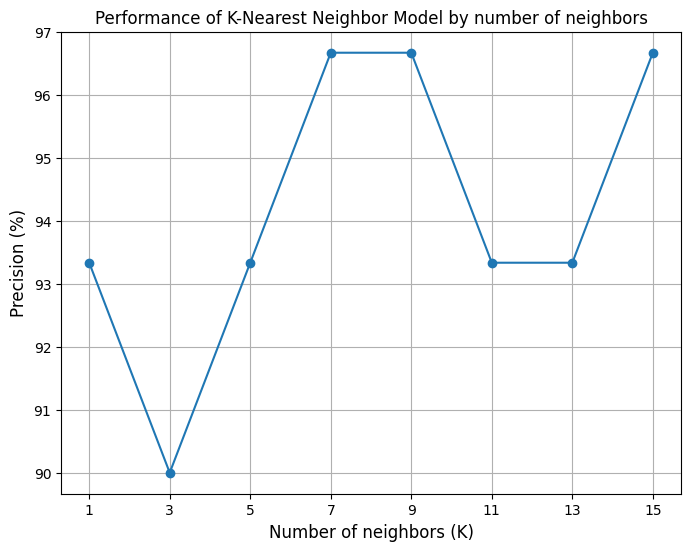

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(k_values, precisionL, marker="o",linestyle="-")
plt.xticks(k_values)
plt.title("Performance of K-Nearest Neighbor Model by number of neighbors")
plt.xlabel("Number of neighbors (K)",fontsize=12)
plt.ylabel("Precision (%)", fontsize=12)
plt.grid()
plt.show()

7. Decision boundary visualization